# ใบงานที่ 2: Data Preprocessing
### วิชา Machine Learning (04-624-201)
**Dataset:**Doraemon Complete Data
**ลิ้งค์อ้างอิง : https://www.kaggle.com/datasets/samasiayushman/doraemon-complete-data

ตรงนี้จะเป็นการ ดึงไลบรารีมาใช้ มีทั้ง pandas , numpy ,matplotlib.pyplot ,seaborn เป็นต้น

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.simplefilter('ignore')          

plt.rcParams['font.family'] = 'Tahoma'

### LAB1: Dataset Exploration

#### 1.1 Load Dataset

ขั้นตอนนี้เป็นการนำชุดข้อมูล (Dataset)รายชื่อตัวละครโดเรม่อนที่ดาวน์โหลดมาจากไฟล์ character_list.csv มาโหลดเข้าสู่โปรแกรมด้วยไลบรารี Pandas เพื่อเตรียมสำหรับการสำรวจและวิเคราะห์ข้อมูลในขั้นตอนถัดไป

In [4]:
df = pd.read_csv("character_list.csv")
df.head()

,Orginal Name,English Name,Gender,Species,Age,Birthd Date,first_appearance,Role,Occupation,Personality,Likes,Dislike,Best Friends,Rivals,Family Member,Voice Actor,Voice Actor ( English ),Signature Gadget,Catch Phrase,Character Designer
0,ドラえもん,Doraemon,Robot,Robot Cat,Unknown,"September 3, 2112",Doraemon's Birth (1979),Main,Nobita's caretaker,"Kind, Helpful, Cowardly","Dorayaki, Helping Nobita","Mice, Being called fat","Nobita, Shizuka","Gian, Suneo",Dorami (sister),Wasabi Mizuta,Mona Marshall,"Anywhere Door, Time Machine",Nobi-kun!,Fujiko F. Fujio
1,野比 のび太,Nobita Nobi,Male,Human,10,August 7,Episode 1,Main,Elementary Student,"Lazy, Clumsy, Good-hearted","Sleeping, Playing","Homework, Gian's bullying","Doraemon, Shizuka","Gian, Suneo","Tamako (Mom), Nobisuke (Dad)",Megumi Ōhara,Johnny Yong Bosch,None (borrows gadgets),"Doraemon, help me!",Fujiko F. Fujio
2,源 静香,Shizuka Minamoto,Female,Human,10,October 20,Episode 1,Main,Elementary Student,"Kind, Intelligent, Gentle","Bathing, Violin","Dirt, Creepy bugs","Nobita, Doraemon",NaN,"Mother, Father",Yumi Kakazu,Johnny Yong Bosch,NaN,"Nobita-kun, ganbatte!",Fujiko F. Fujio
3,剛田 武,Gian (Takeo Goda),Male,Human,11,June 15,Episode 1,Main,Elementary Student,"Bully, Loud, Music-lover","Singing, Meat","Losing, Being ignored","Suneo, Nobita (reluctantly)",Nobita,"Mother, Father",Subaru Kimura,Kaiji Tang,NaN,Singing terribly,Fujiko F. Fujio
4,骨川 スネ夫,Suneo Honekawa,Male,Human,10,February 29,Episode 1,Main,Elementary Student,"Vain, Sneaky, Rich","Showing off, New gadgets","Being poor, Gian's bullying","Gian, Shizuka",Nobita,"Mother, Father",Tomokazu Seki,Brian Beacock,NaN,I’m better than you!,Fujiko F. Fujio


#### 1.2 Display Shape

ตรงนี้เป็นการตรวจสอบขนาดของชุดข้อมูล (Dataset Shape) เพื่อดูจำนวนแถว (Rows) และจำนวนคอลัมน์ (Columns) ในคำสั่งเดียว ซึ่งช่วยให้ทราบขนาดของข้อมูลก่อนเริ่มกระบวนการวิเคราะห์และทำ Data Preprocessing

In [5]:
print(df.shape)  # (จำนวนแถว, จำนวนคอลัมน์)

(100, 20)


#### 1.3 Display Data Types

ขั้นตอนนี้ตรวจสอบชนิดข้อมูล (Data Types) ของแต่ละคอลัมน์ในชุดข้อมูล เพื่อทราบว่าคอลัมน์ใดเป็นข้อความ (object) และคอลัมน์ใดเป็นตัวเลข (int64/float64) 

In [6]:
print(df.dtypes)

Orginal Name               str
English Name               str
Gender                     str
Species                    str
Age                        str
Birthd Date                str
first_appearance           str
Role                       str
Occupation                 str
Personality                str
Likes                      str
Dislike                    str
Best Friends               str
Rivals                     str
Family Member              str
Voice Actor                str
Voice Actor ( English )    str
Signature Gadget           str
Catch Phrase               str
Character Designer         str
dtype: object


#### 1.4 Display Summary Statistics

ขั้นตอนนี้แสดงสถิติสรุปเบื้องต้น (Summary Statistics) ของข้อมูลทุกคอลัมน์ในคำสั่งเดียว เพื่อให้เห็นภาพรวมลักษณะของข้อมูลก่อนเริ่มกระบวนการทำความสะอาดและวิเคราะห์เชิงลึก

In [7]:
df.describe(include='all')

,Orginal Name,English Name,Gender,Species,Age,Birthd Date,first_appearance,Role,Occupation,Personality,Likes,Dislike,Best Friends,Rivals,Family Member,Voice Actor,Voice Actor ( English ),Signature Gadget,Catch Phrase,Character Designer
count,100,100,99,100,100,100,100,100,100,100,100,100,77,26,46,98,100,66,100,100
unique,100,100,4,18,18,14,49,11,72,98,93,90,46,12,28,44,8,66,100,1
top,ドラえもん,Doraemon,Male,Human,Unknown,Unknown,Doraemon: Nobita's Robot Kingdom (2002),Movie Supporting,Elementary Student,"Innocent, Playful, Curious","Gold, Power",Oppression,"Nobita, Doraemon","Doraemon, Nobita",Parents,Kappei Yamaguchi,(English VA),"Anywhere Door, Time Machine",Nobi-kun!,Fujiko F. Fujio
freq,1,1,59,51,36,84,9,53,9,2,3,3,16,7,12,7,92,1,1,100


#### 1.5 Display Missing Values

ขั้นตอนนี้ตรวจสอบว่าคอลัมน์ใดในชุดข้อมูลมีค่าที่หายไป (Missing Values) บ้าง และหายไปกี่แถว 

In [8]:
print(df.isnull().sum())

Orginal Name                0
English Name                0
Gender                      1
Species                     0
Age                         0
Birthd Date                 0
first_appearance            0
Role                        0
Occupation                  0
Personality                 0
Likes                       0
Dislike                     0
Best Friends               23
Rivals                     74
Family Member              54
Voice Actor                 2
Voice Actor ( English )     0
Signature Gadget           34
Catch Phrase                0
Character Designer          0
dtype: int64


#### 1.6 Display Duplicate Records

ขั้นตอนนี้ตรวจสอบว่ามีแถวข้อมูลที่ซ้ำกันทุกคอลัมน์อยู่ในชุดข้อมูลกี่แถว หากมีข้อมูลซ้ำจะต้องพิจารณาลบออกในขั้นตอน Data Cleaning (Part 3) เพื่อไม่ให้ตัวละครถูกนับซ้ำจนกระทบผลการวิเคราะห์

In [9]:
print(df.duplicated().sum())

0


#### 1.7 Display Class Distribution

ขั้นตอนนี้ตรวจสอบการกระจายตัวของข้อมูลในคอลัมน์ Role เพื่อดูว่าตัวละครแต่ละประเภท (เช่น Main, Supporting, Villain) มีจำนวนเท่าใด ทั้งในรูปแบบตัวเลขและกราฟ ซึ่งช่วยให้ทราบว่าข้อมูลมีความสมดุล (Balance) หรือไม่สมดุล (Imbalance) หากนำไปใช้ทำโมเดลจำแนกประเภท

Role
Movie Supporting    53
Movie Antagonist    14
Recurring            9
Minor                6
Main                 5
Flashback            3
Manga Exclusive      3
Supporting           2
Special              2
Alternate            2
Movie Recurring      1
Name: count, dtype: int64


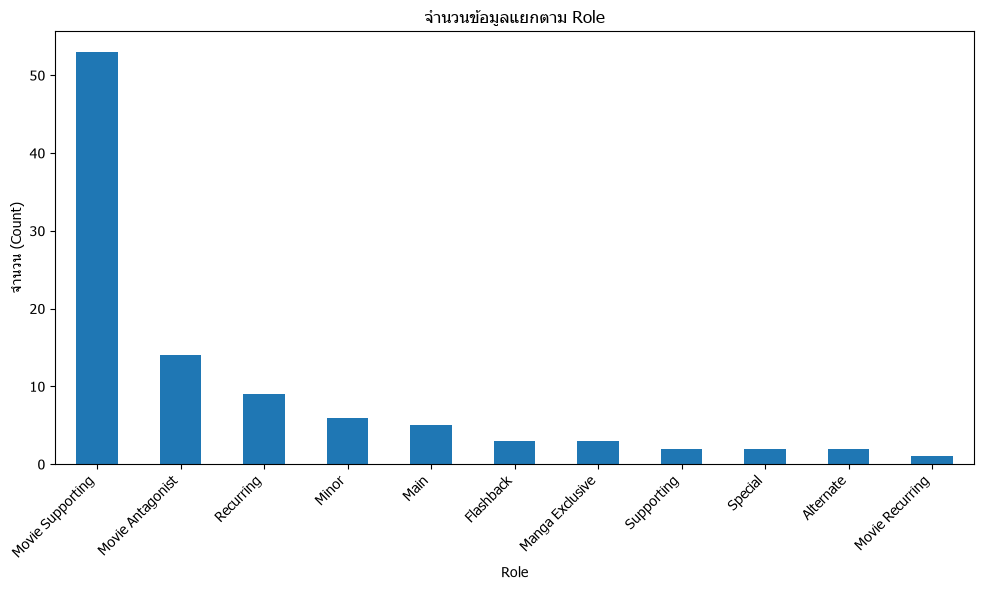

In [ ]:
col = 'Role'  

counts = df[col].value_counts()
print(counts)

plt.figure(figsize=(10, 6))
counts.plot(kind='bar')
plt.title(f'จำนวนข้อมูลแยกตาม {col}')
plt.xlabel(col)
plt.ylabel('จำนวน (Count)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### check Number

ตรงนี้เพิ่มมาเพราะว่าก่อนเริ่มวาด Histogram และ Correlation Heatmap ตามที่ใบงาน LAB2 กำหนด ต้องตรวจสอบก่อนว่าชุดข้อมูลมีคอลัมน์ตัวเลขอยู่กี่คอลัมน์ เพราะทั้งสองเทคนิคนี้ใช้ได้เฉพาะกับข้อมูลประเภทตัวเลขเท่านั้น

In [46]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("คอลัมน์ตัวเลขที่มี:", list(numeric_cols))

คอลัมน์ตัวเลขที่มี: ['Age_numeric']


ขั้นตอนนี้แปลงคอลัมน์ Age ซึ่งเดิมถูกเก็บเป็นข้อความ (object) ให้กลายเป็นตัวเลขจริง เนื่องจากค่าส่วนใหญ่ในคอลัมน์นี้เป็นตัวเลข (เช่น '10', '38', '100') แต่มีคำว่า 'Unknown' ปนอยู่ ทำให้ Pandas อ่านทั้งคอลัมน์เป็นข้อความไปด้วย จำเป็นต้องแปลงก่อนถึงจะนำไปทำ Histogram, Correlation Heatmap และ Mean/Median

In [ ]:
df['Age_numeric'] = pd.to_numeric(df['Age'], errors='coerce')
print(df['Age_numeric'].describe())
print("จำนวนแถวที่แปลงไม่ได้ (Unknown → NaN):", df['Age_numeric'].isnull().sum())

count      64.000000
mean       38.359375
std       128.428273
min         5.000000
25%        10.000000
50%        10.000000
75%        12.000000
max      1000.000000
Name: Age_numeric, dtype: float64
จำนวนแถวที่แปลงไม่ได้ (Unknown → NaN): 36


### LAB2: Data Visualization

#### 2.1 Histogram

เนื่องจากใบงาน LAB2 กำหนดให้ทำ Histogram แต่ Histogram ใช้ได้เฉพาะกับข้อมูลตัวเลขต่อเนื่องเท่านั้น และชุดข้อมูล Doraemon นี้มีคอลัมน์ตัวเลขจริงแค่ Age_numeric คอลัมน์เดียว โค้ดชุดนี้จึงใช้ bar chart ของ value_counts() แทน เพื่อดูการกระจายตัวของคอลัมน์ข้อความ (categorical) ที่มีอยู่เป็นส่วนใหญ่ในไฟล์นี้ซึ่งทำหน้าที่เดียวกันคือแสดงการกระจายตัวของข้อมูล จึงได้กราฟมา 3 กราฟค่ะ

คอลัมน์ข้อความที่มี: ['Orginal Name', 'English Name', 'Gender', 'Species', 'Age', 'Birthd Date', 'first_appearance', 'Role', 'Occupation', 'Personality', 'Likes', 'Dislike', 'Best Friends', 'Rivals', 'Family Member', 'Voice Actor ', 'Voice Actor ( English )', 'Signature Gadget', 'Catch Phrase', 'Character Designer']


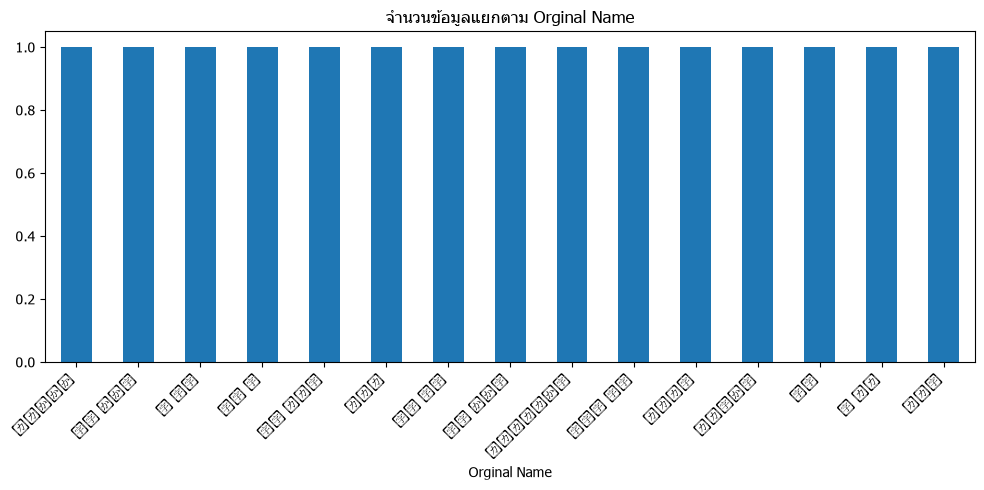

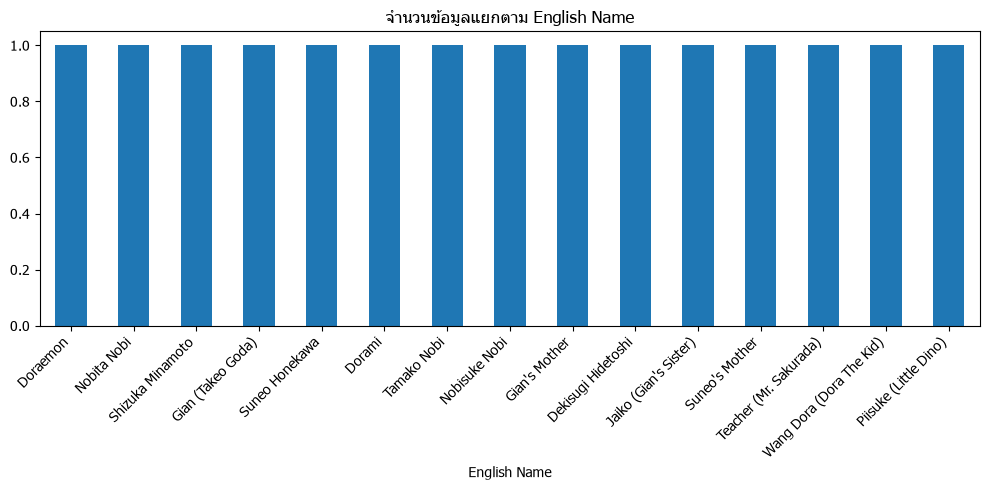

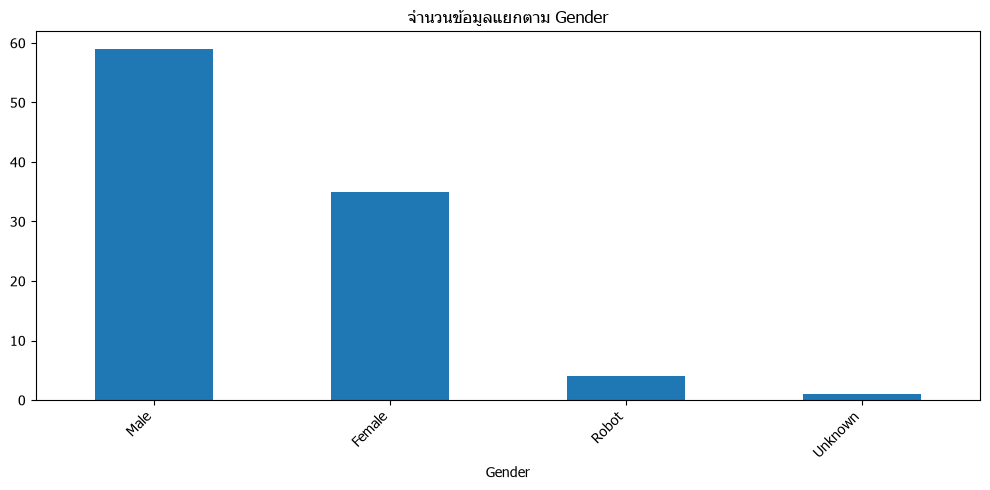

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
print("คอลัมน์ข้อความที่มี:", list(categorical_cols))

for col in categorical_cols[:3]:  
    plt.figure(figsize=(10, 5))
    df[col].value_counts().head(15).plot(kind='bar')  
    plt.title(f'จำนวนข้อมูลแยกตาม {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#### 2.2 Correlation Heatmap

กำหนดให้ทำ Correlation Heatmap แต่เทคนิคนี้ต้องการตัวแปรตัวเลขอย่างน้อย 2 คอลัมน์ ในขณะที่ชุดข้อมูล Doraemon มีตัวเลขจริงแค่ Age_numeric คอลัมน์เดียว จึงใช้ Crosstab Heatmap แทน เพื่อดูความสัมพันธ์ระหว่างตัวแปรข้อความ (categorical) สองตัวแทน ซึ่งให้แนวคิดเดียวกันคือ "ดูความสัมพันธ์ระหว่างตัวแปร"เพียงแต่ปรับวิธีวัดให้เหมาะกับข้อมูลประเภทหมวดหมู่่

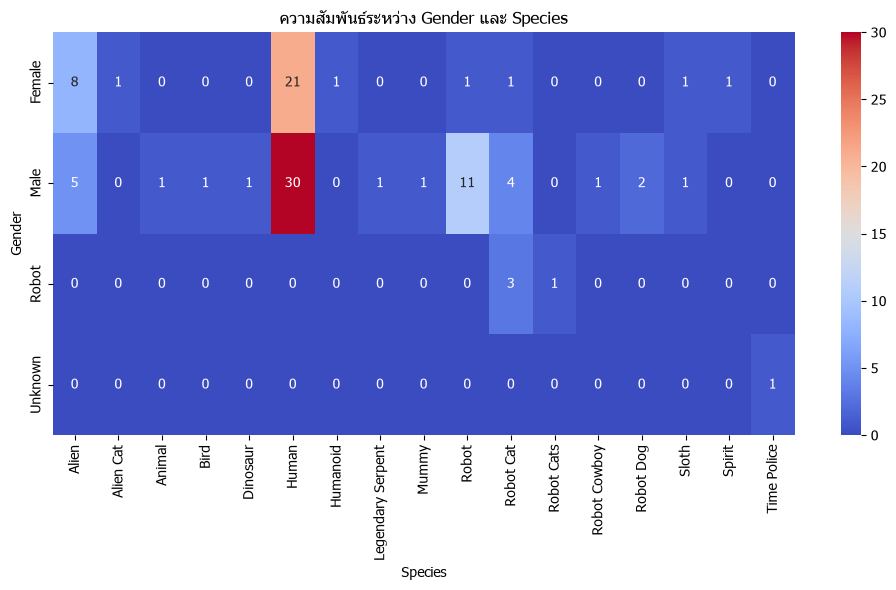

In [29]:
if 'Gender' in df.columns and 'Species' in df.columns:
    ct = pd.crosstab(df['Gender'], df['Species'])
    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, cmap='coolwarm', fmt='d')
    plt.title('ความสัมพันธ์ระหว่าง Gender และ Species')
    plt.tight_layout()
    plt.show()

### Part3: Data Cleaning

#### 3.1 Missing Value Handling

ก่อนแก้ไขข้อมูลใน Part 3 ต้องสำเนา df เก็บไว้เป็น df_clean ก่อน แล้วแก้ไขทุกอย่างบน df_clean แทน เพื่อให้ df ต้นฉบับยังอยู่ครบ เผื่อแก้พลาดจะได้มีของเดิมย้อนกลับไปดูได้

In [49]:
df_clean = df.copy()

ขั้นตอนนี้คือการทำ Data Cleaning เพื่อจัดการกับข้อมูลที่สูญหายหรือเป็นช่องว่าง (Missing Values) ในทุกคอลัมน์ของชุดข้อมูลตัวละครโดเรม่อน

In [32]:
for col in df_clean.columns:
    if df_clean[col].isnull().sum() == 0:
        continue
    if df_clean[col].dtype in [np.float64, np.int64]:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    else:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values หลังแก้ไข:", df_clean.isnull().sum().sum())

Missing values หลังแก้ไข: 0


#### 3.2 Duplicate Removal

ขั้นตอนนี้คือการทำ Data Cleaning เพื่อตรวจสอบและลบแถวข้อมูลที่ซ้ำกันออกจากชุดข้อมูล

In [33]:
print("ก่อนลบซ้ำ:", df_clean.shape[0])
df_clean = df_clean.drop_duplicates()
print("หลังลบซ้ำ:", df_clean.shape[0])


ก่อนลบซ้ำ: 100
หลังลบซ้ำ: 100


#### 3.3 Incorrect Data Correction

ขั้นตอนนี้คือการตรวจสอบข้อมูลที่ผิดตรรกะ (Incorrect Data) ในคอลัมน์ตัวเลข เช่น ค่าอายุติดลบ ซึ่งเป็นไปไม่ได้ในความเป็นจริง

In [ ]:
for col in df_clean.select_dtypes(include=[np.number]).columns:
    n_negative = (df_clean[col] < 0).sum()
    if n_negative > 0:
        print(f"'{col}' มีค่าติดลบผิดปกติ {n_negative} แถว")
    else:
        print(f"'{col}' ไม่มีค่าติดลบผิดปกติ")   

'Age_numeric' ไม่มีค่าติดลบผิดปกติ


#### 3.4 Data Type Conversion

ขั้นตอนนี้คือการแปลงชนิดข้อมูล (Data Type Conversion) ของคอลัมน์ Role และ Gender จาก object (ข้อความทั่วไป) ให้เป็น category (ข้อมูลเชิงหมวดหมู่)

In [ ]:

cols_to_convert = ['Role', 'Gender']   

print("ชนิดข้อมูลก่อนแปลง:")
print(df_clean[cols_to_convert].dtypes)

for col in cols_to_convert:
    df_clean[col] = df_clean[col].astype('category')

print("\nชนิดข้อมูลหลังแปลง:")
print(df_clean[cols_to_convert].dtypes)

ชนิดข้อมูลก่อนแปลง:
Role      category
Gender    category
dtype: object

ชนิดข้อมูลหลังแปลง:
Role      category
Gender    category
dtype: object


#### 3.5 Compare Mean VS Median

การเปรียบเทียบค่าเฉลี่ย (Mean) และค่ามัธยฐาน (Median) ของคอลัมน์ตัวเลขในชุดข้อมูล เพื่อดูว่ามีค่าผิดปกติแฝงอยู่หรือไม่

In [48]:
if len(numeric_cols) > 0:
    for col in numeric_cols:
        print(f"{col} - Mean: {df[col].mean():.2f} | Median: {df[col].median():.2f}")
else:
    print("ไม่มีคอลัมน์ตัวเลขให้เทียบ Mean/Median ในไฟล์นี้")

Age_numeric - Mean: 38.36 | Median: 10.00


### Part4: Feature Engineering

#### 4.1 Label Encoding

การทำ Feature Engineering เพื่อแปลงคอลัมน์ Role ซึ่งเป็นข้อความ ให้กลายเป็นตัวเลข เพราะโมเดล Machine Learning คำนวณได้เฉพาะกับตัวเลขเท่านั้น

In [51]:
le = LabelEncoder()
df_clean['Role_encoded'] = le.fit_transform(df_clean['Role'].astype(str))
print(df_clean[['Role', 'Role_encoded']].head(10))


         Role  Role_encoded
0        Main             2
1        Main             2
2        Main             2
3        Main             2
4        Main             2
5   Recurring             8
6  Supporting            10
7  Supporting            10
8   Recurring             8
9   Recurring             8


#### 4.2 One-Hot Encoding

การแปลงคอลัมน์ Gender ซึ่งเป็นข้อความ ให้กลายเป็นตัวเลขในรูปแบบ 0/1 แทน เพราะ Gender เป็นข้อมูลหมวดหมู่ที่ไม่มีลำดับความสำคัญ

In [52]:
print("Gender มีค่าไม่ซ้ำ:", df_clean['Gender'].nunique())
df_encoded = pd.get_dummies(df_clean, columns=['Gender'], prefix='Gender')
df_encoded.head()

Gender มีค่าไม่ซ้ำ: 4


,Orginal Name,English Name,Species,Age,Birthd Date,first_appearance,Role,Occupation,Personality,Likes,...,Voice Actor ( English ),Signature Gadget,Catch Phrase,Character Designer,Age_numeric,Role_encoded,Gender_Female,Gender_Male,Gender_Robot,Gender_Unknown
0,ドラえもん,Doraemon,Robot Cat,Unknown,"September 3, 2112",Doraemon's Birth (1979),Main,Nobita's caretaker,"Kind, Helpful, Cowardly","Dorayaki, Helping Nobita",...,Mona Marshall,"Anywhere Door, Time Machine",Nobi-kun!,Fujiko F. Fujio,NaN,2,False,False,True,False
1,野比 のび太,Nobita Nobi,Human,10,August 7,Episode 1,Main,Elementary Student,"Lazy, Clumsy, Good-hearted","Sleeping, Playing",...,Johnny Yong Bosch,None (borrows gadgets),"Doraemon, help me!",Fujiko F. Fujio,10.0,2,False,True,False,False
2,源 静香,Shizuka Minamoto,Human,10,October 20,Episode 1,Main,Elementary Student,"Kind, Intelligent, Gentle","Bathing, Violin",...,Johnny Yong Bosch,NaN,"Nobita-kun, ganbatte!",Fujiko F. Fujio,10.0,2,True,False,False,False
3,剛田 武,Gian (Takeo Goda),Human,11,June 15,Episode 1,Main,Elementary Student,"Bully, Loud, Music-lover","Singing, Meat",...,Kaiji Tang,NaN,Singing terribly,Fujiko F. Fujio,11.0,2,False,True,False,False
4,骨川 スネ夫,Suneo Honekawa,Human,10,February 29,Episode 1,Main,Elementary Student,"Vain, Sneaky, Rich","Showing off, New gadgets",...,Brian Beacock,NaN,I’m better than you!,Fujiko F. Fujio,10.0,2,False,True,False,False


In [ ]:
สรุป

LAB1: สำรวจ dataset ตัวละครโดเรม่อน พบว่าทุกคอลัมน์เป็นข้อความ (Character, Role, Gender, Species ฯลฯ) ยกเว้น Age ที่แปลงเป็นตัวเลขได้ พบ missing values บางส่วน และคอลัมน์ Role มีการกระจายตัวไม่สมดุล (class imbalance)
LAB2: เนื่องจากมีตัวแปรตัวเลขไม่พอ (แค่ Age คอลัมน์เดียว) จึงใช้ bar chart แสดงจำนวนตัวละครแยกตาม Role แทน histogram และใช้ crosstab heatmap แสดงความสัมพันธ์ระหว่าง Gender กับ Species แทน correlation heatmap
Part 3: เติมค่า missing ด้วย median (คอลัมน์ตัวเลข) และ mode (คอลัมน์ข้อความ), ลบแถวซ้ำ, ตรวจค่าติดลบผิดปกติ, แปลงชนิดข้อมูล Role และ Gender เป็น category
Part 4: ใช้ Label Encoding กับ Role (มีหลายหมวดหมู่) และ One-Hot Encoding กับ Gender (มีหมวดหมู่น้อยและไม่มีลำดับ)

### จัดทำโดย

** นางสาวกวินธิดา สุขโฉม 116710400602-4 sec2